In [4]:
from utils import * 

%load_ext autoreload
%autoreload 2

plot_configure_mpl(figure_height=2.5, label_font_size=5, title_font_size=5)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# SI Figure 3

In [5]:
# "Minimal list" of feature types.
feature_types = ['ko', 'embedding_oxygen_genes', 'embedding_genome', 'chemical', 'aa_1mer', 'aa_3mer']

# Load the model training results. 
nonlinear_results = dict()
logistic_results = dict()

for feature_type in feature_types:
    nonlinear_results[feature_type] = load_results_dict(os.path.join(results_dir, f'train_nonlinear_{feature_type}_ternary.json'))
    logistic_results[feature_type] = load_results_dict(os.path.join(results_dir, f'train_logistic_{feature_type}_ternary.json'))

In [6]:
def plot_si_figure_3a(logistic_results:Dict, fig:plt.Figure=None, grids:List[GridSpec]=None):
    '''Plots the first row of confusion matrices, which display results for nonlinear classifiers.'''
    axes = []
    for i, feature_type in enumerate(feature_types):
        ax = fig.add_subplot(grids[i])
        plot_confusion_matrix(logistic_results[feature_type], ax=ax)
        if i != 0: # Turn of the tick labels for the y-axis for all except the leftmost plot.
            ax.set_yticks([])
        else:
            ax.set_ylabel('linear models\n\ntrue label')
        # ax.set_title(f'{PRETTY_NAMES[feature_type]} (Logistic)') # I think it's OK to turn off the title. 
        ax.set_title(f'{PRETTY_NAMES[feature_type]}') # I think it's OK to turn off the title. 
        axes.append(ax)
    return axes

In [7]:
def plot_si_figure_3b(nonlinear_results:Dict, fig:plt.Figure=None, grids:List[GridSpec]=None):
    '''Plots the first row of confusion matrices, which display results for logistic classifiers.'''
    axes = [] 
    for i, feature_type in enumerate(feature_types):
        ax = fig.add_subplot(grids[i])
        plot_confusion_matrix(nonlinear_results[feature_type], ax=ax)
        # Turn of the tick labels for all y-axes except the one to the far left. 
        if i != 0:
            ax.set_yticks([])
        else:
            ax.set_ylabel('nonlinear models\n\ntrue label')
        ax.set_xlabel('predicted label') # Not sure why the x-label is getting removed?
        #ax.set_title(f'{PRETTY_NAMES[feature_type]}') # I think it's OK to turn off the title. 
        axes.append(ax)
    return axes

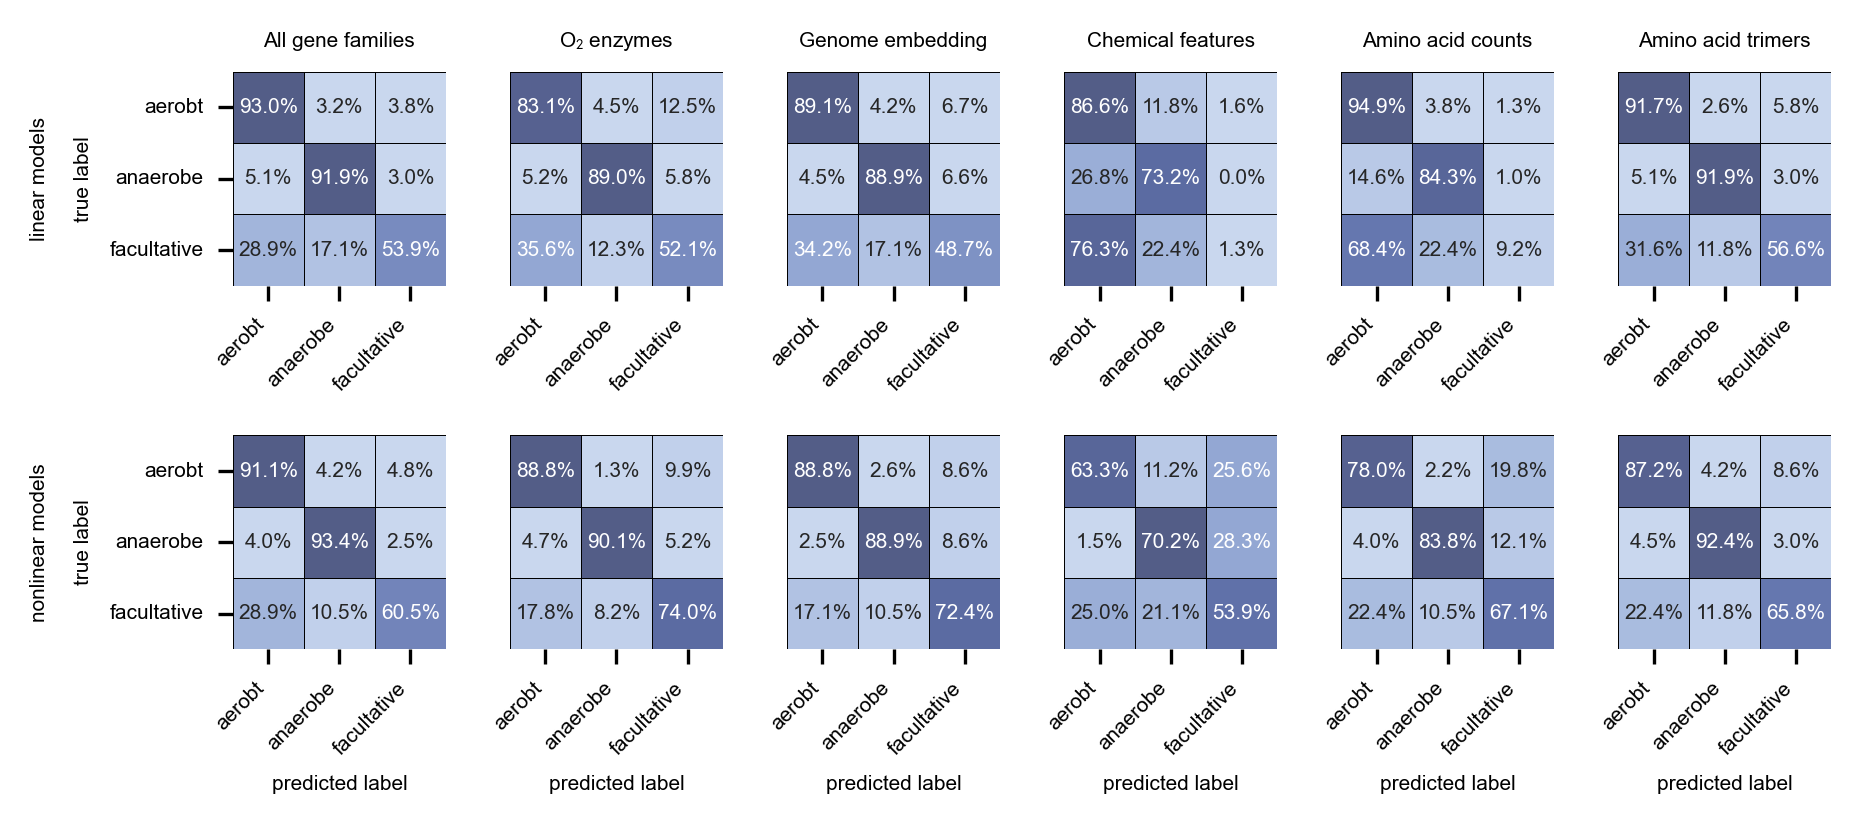

In [8]:
fig = plt.figure()
grid = GridSpec(2, len(feature_types), hspace=0.7, wspace=0.3)

axes = plot_si_figure_3a(logistic_results, fig=fig, grids=[grid[0, i] for i in range(len(feature_types))])
axes += plot_si_figure_3b(nonlinear_results, fig=fig, grids=[grid[1, i] for i in range(len(feature_types))])

# for ax, ax_label in zip(axes, 'ABCDEFGHIJKL'):
#     ax.set_title(ax_label, loc='left', fontweight='bold')

plt.savefig(os.path.join(figures_dir, 'si_fig3.png'), dpi=300, facecolor='w', bbox_inches='tight')
plt.show()